# Neural Network For Handwritten Digit Recognition Using Tensorflow

## Importing Essential Packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns

from PIL import Image

import tensorflow as tf

from tensorflow.keras import models, layers
from tensorflow.keras.utils import image_dataset_from_directory

## Inspecting Dataset

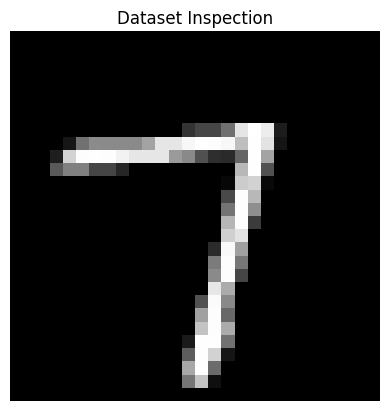

In [2]:
inspection_img = Image.open("../data/mnistmini/training/7/10640.png")

plt.title("Dataset Inspection")

plt.imshow(inspection_img, cmap = "gray")
plt.axis("off")

plt.show()

## Loading Dataset

In [4]:
train_dataset = image_dataset_from_directory(
    "../data/mnistmini/training",
    validation_split = 0.2,
    subset = "training",
    seed = 7,
    color_mode = "grayscale",
    image_size = (28, 28),
    batch_size = 64
)

validation_dataset = image_dataset_from_directory(
    "../data/mnistmini/training",
    validation_split = 0.2,
    subset = "validation",
    seed = 7,
    color_mode = "grayscale",
    image_size = (28, 28),
    batch_size = 64
)

testing_dataset = image_dataset_from_directory(
    "../data/mnistmini/testing",
    color_mode = "grayscale",
    image_size = (28, 28),
    batch_size = 64,
    shuffle = False
    
)

Found 1000 files belonging to 10 classes.
Using 800 files for training.
Found 1000 files belonging to 10 classes.
Using 200 files for validation.
Found 200 files belonging to 10 classes.


## Model Architechture and Creation

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomTranslation(0.1, 0.1)
])

In [13]:
model = models.Sequential([
    tf.keras.Input(shape = (28, 28, 1)),

    layers.Rescaling(1./255),
    data_augmentation,
    layers.Flatten(),

    layers.Dense(256, activation = 'relu'),
    layers.Dense(128, activation = 'relu'),
    layers.Dense(64, activation = 'relu'),

    layers.Dense(10)
    
])

In [14]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics = ['accuracy']
)

In [15]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 50
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - accuracy: 0.2850 - loss: 2.1092 - val_accuracy: 0.5200 - val_loss: 1.6930
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.4925 - loss: 1.6464 - val_accuracy: 0.7250 - val_loss: 1.1381
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6162 - loss: 1.2704 - val_accuracy: 0.6750 - val_loss: 0.9728
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6087 - loss: 1.1542 - val_accuracy: 0.7050 - val_loss: 0.7546
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6925 - loss: 0.9760 - val_accuracy: 0.7700 - val_loss: 0.6548
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7138 - loss: 0.8922 - val_accuracy: 0.8200 - val_loss: 0.5598
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7400 - loss: 0.7862 - val_accuracy: 0.8350 - val_loss: 0.4977
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7575 - loss: 0.7493 - val_accuracy: 0.8500 - 

## Model Evaluation

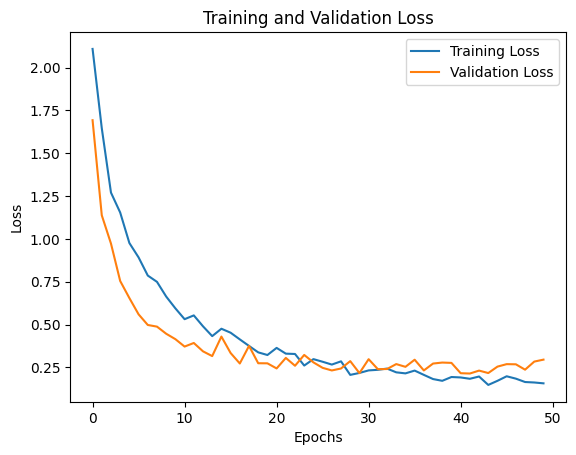

In [21]:
plt.title("Training and Validation Loss")

plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
# plt.grid(True)

plt.show()

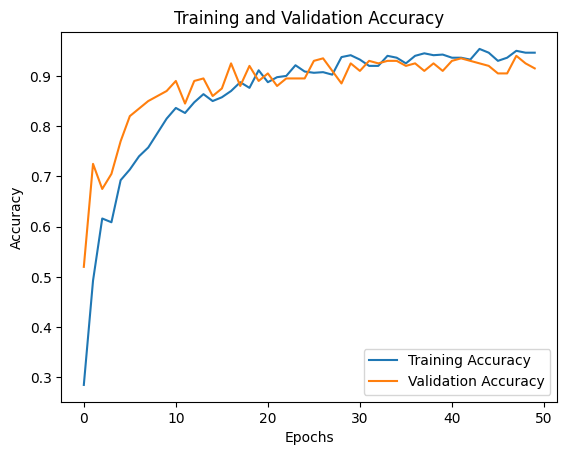

In [23]:
plt.title("Training and Validation Accuracy")

plt.plot(history.history['accuracy'], label = "Training Accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
# plt.grid(True)

plt.show()

In [17]:
y_true = np.concatenate([y for x, y in testing_dataset])

logits = model.predict(testing_dataset)
y_preds = np.argmax(logits, axis = 1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


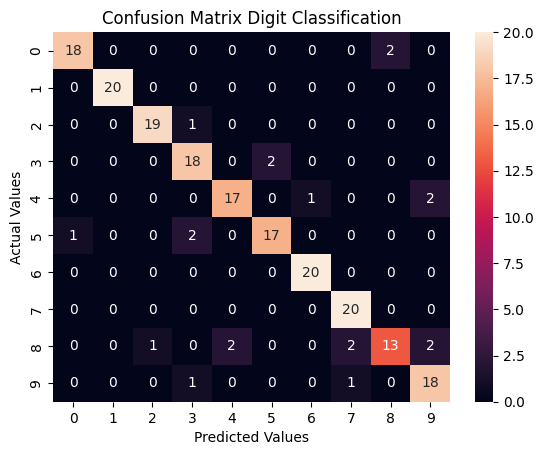

In [18]:
cm = confusion_matrix(y_true, y_preds)

plt.title("Confusion Matrix Digit Classification")

sns.heatmap(cm, annot = True)
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

plt.show()

In [25]:
print(classification_report(y_true, y_preds))

              precision    recall  f1-score   support

           0       0.95      0.90      0.92        20
           1       1.00      1.00      1.00        20
           2       0.95      0.95      0.95        20
           3       0.82      0.90      0.86        20
           4       0.89      0.85      0.87        20
           5       0.89      0.85      0.87        20
           6       0.95      1.00      0.98        20
           7       0.87      1.00      0.93        20
           8       0.87      0.65      0.74        20
           9       0.82      0.90      0.86        20

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



## Saving the Model and Making Inferences

In [31]:
model.save("../models/digit_tensorflow_model.keras")

In [3]:
saved_model = tf.keras.models.load_model("../models/digit_tensorflow_model.keras")

In [15]:
def predict_digit(image_path):
    image = Image.open(image_path).convert("L")
    
    plt.title("Acutal Digit")
    plt.imshow(image, cmap = "gray")
    plt.axis("off")
    plt.show()

    image = image.resize((28, 28))

    img_array = np.array(image, dtype = np.float32)
    img_array = np.expand_dims(img_array, axis = -1)
    img_array = np.expand_dims(img_array, axis = 0)

    logits = saved_model.predict(img_array)
    predict_digit = np.argmax(logits, axis = 1)

    print(f"Predicted Digit: {predict_digit[0]}")

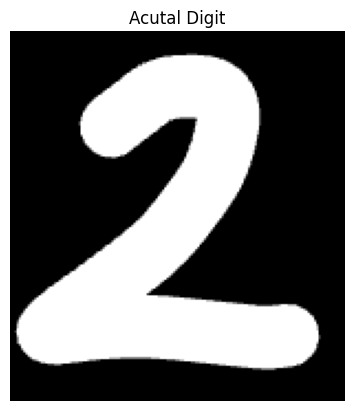

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted Digit: 2


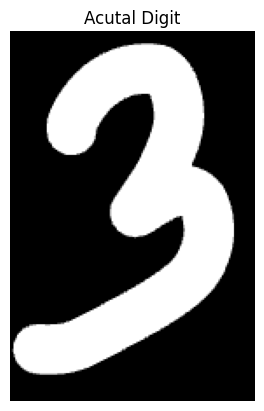

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted Digit: 3


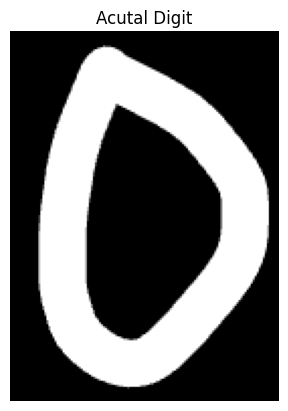

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted Digit: 0


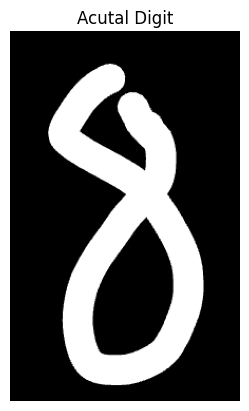

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Predicted Digit: 8


In [16]:
predict_digit('../data/mnistmini/extra/Two.png')
predict_digit('../data/mnistmini/extra/Three.png')
predict_digit('../data/mnistmini/extra/Zero.png')
predict_digit('../data/mnistmini/extra/Eight.png')